# Evaluation result for RF

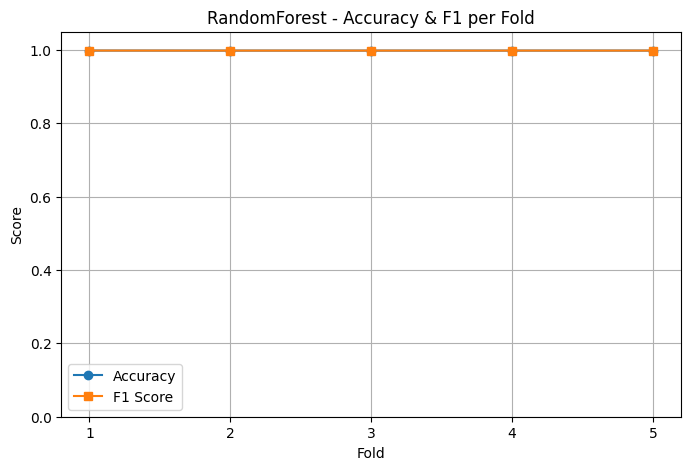

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Path to saved metrics JSON
json_path = "../cicids2017/results/rf_metrics.json"  

with open(json_path, "r") as f:
    metrics_all = json.load(f)

# Check structure
list(metrics_all.keys())

model_name = "RandomForest"  # replace as needed
folds = metrics_all[model_name]

# Extract metrics
accuracy = [fold['accuracy'] for fold in folds]
f1_score_vals = [fold['f1'] for fold in folds]

# Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(range(1, len(accuracy)+1), accuracy, marker='o', label='Accuracy')
plt.plot(range(1, len(f1_score_vals)+1), f1_score_vals, marker='s', label='F1 Score')
plt.title(f'{model_name} - Accuracy & F1 per Fold')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.ylim(0,1.05)
plt.xticks(range(1, len(accuracy)+1))
plt.grid(True)
plt.legend()
plt.show()


In [4]:
avg_accuracy = np.mean([fold['accuracy'] for fold in folds])
avg_f1 = np.mean([fold['f1'] for fold in folds])
avg_precision = np.mean([fold['precision'] for fold in folds])
avg_recall = np.mean([fold['recall'] for fold in folds])
avg_roc_auc = np.mean([fold['roc_auc'] for fold in folds if fold['roc_auc'] is not None])

print(f"{model_name} - Average Metrics Across {len(folds)} Folds")
print(f"Accuracy: {avg_accuracy:.4f}")
print(f"F1 Score: {avg_f1:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall: {avg_recall:.4f}")
print(f"ROC AUC: {avg_roc_auc:.4f}")


RandomForest - Average Metrics Across 5 Folds
Accuracy: 0.9986
F1 Score: 0.9985
Precision: 0.9985
Recall: 0.9986
ROC AUC: 0.9869


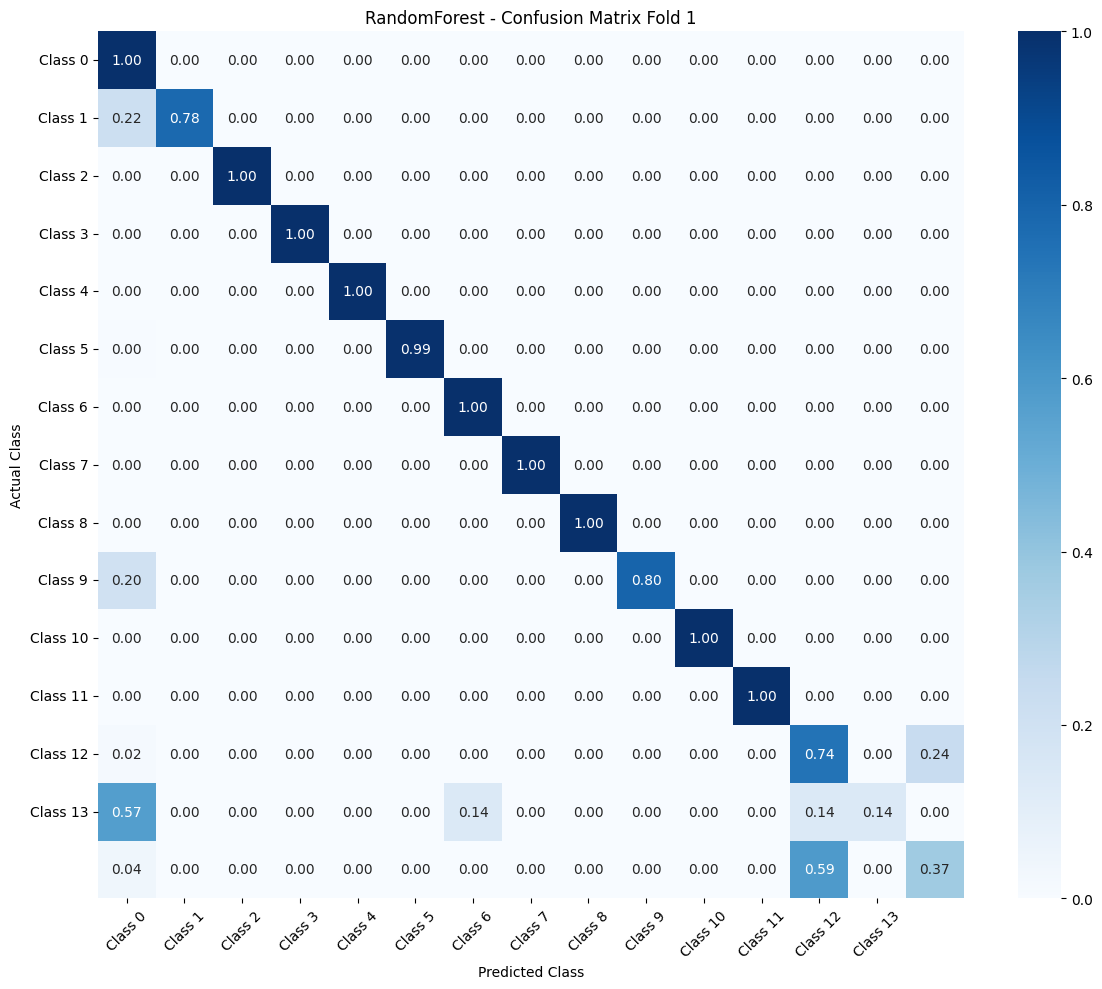

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(cm, class_names=None, fold_num=1, model_name="Model", normalize=True):
    """
    cm: confusion matrix (numpy array)
    class_names: list of class labels
    fold_num: fold number for title
    model_name: name of the model
    normalize: whether to normalize by row (per-class)
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12,10))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap="Blues", cbar=True,
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title(f"{model_name} - Confusion Matrix Fold {fold_num}")
    plt.ylabel("Actual Class")
    plt.xlabel("Predicted Class")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
# Example usage:
fold_num = 1
cm = np.array(metrics_all['RandomForest'][fold_num-1]['confusion_matrix'])
class_names = [f"Class {i}" for i in range(14)]  # replace with your actual class names if you have
plot_confusion_matrix(cm, class_names=class_names, fold_num=fold_num, model_name="RandomForest")




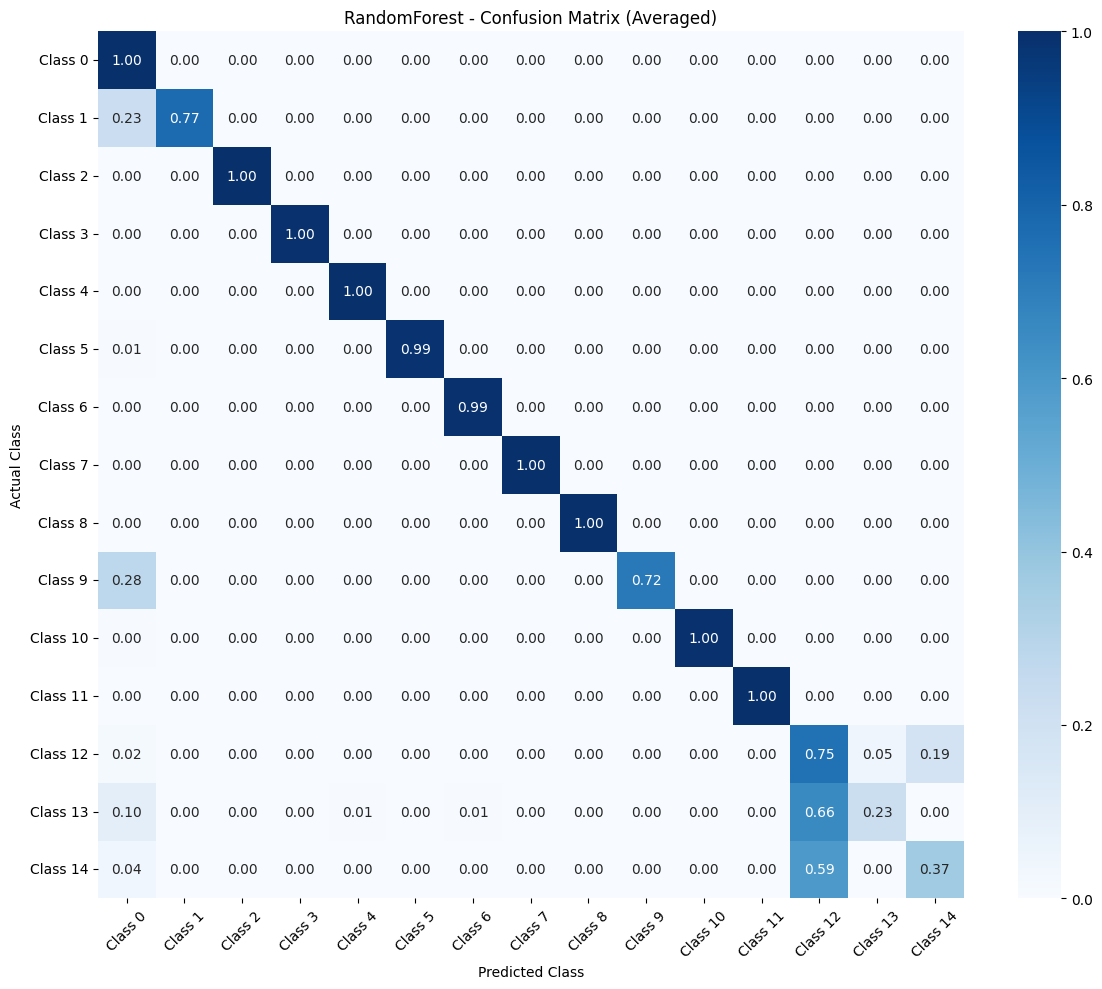

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(cm, class_names=None, fold_num=None, model_name="Model", normalize=True):
    """
    cm: confusion matrix (numpy array)
    class_names: list of class labels
    fold_num: fold number for title (None for averaged matrix)
    model_name: name of the model
    normalize: whether to normalize by row (per-class)
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap="Blues", cbar=True,
                xticklabels=class_names, yticklabels=class_names)

    title = f"{model_name} - Confusion Matrix"
    if fold_num is not None:
        title += f" Fold {fold_num}"
    else:
        title += " (Averaged)"

    plt.title(title)
    plt.ylabel("Actual Class")
    plt.xlabel("Predicted Class")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Visualize confusion matrices for each fold
conf_matrices = [
    np.array(fold['confusion_matrix']) for fold in metrics_all['RandomForest']
]

class_names = [f"Class {i}" for i in range(conf_matrices[0].shape[0])]  # Replace with actual class names if available

for fold_num, cm in enumerate(conf_matrices, start=1):
    plot_confusion_matrix(cm, class_names=class_names, fold_num=fold_num, model_name="RandomForest")

# Compute and visualize the averaged confusion matrix
max_shape = np.max([cm.shape for cm in conf_matrices], axis=0)
conf_matrices_padded = [
    np.pad(cm, [(0, max_shape[0] - cm.shape[0]), (0, max_shape[1] - cm.shape[1])], mode='constant')
    for cm in conf_matrices
]

avg_conf_matrix = np.mean(conf_matrices_padded, axis=0)
plot_confusion_matrix(avg_conf_matrix, class_names=class_names, fold_num=None, model_name="RandomForest")